In [1]:
# ===============================
# 1. Import libraries
# ===============================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [2]:
# ===============================
# 2. Load dataset
# ===============================

df = pd.read_csv("heart_statlog_cleveland_hungary_final.csv")

df.head()

,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [3]:
# ===============================
# 3. Clean column names
# ===============================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.head()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


In [4]:
# Check columns
print(df.columns)

Index(['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'oldpeak', 'st_slope', 'target'],
      dtype='object')


In [5]:
# ===============================
# 4. Basic data checking
# ===============================

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget values:")
print(df["target"].value_counts())

Shape: (1190, 12)

Missing values:
age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
target                 0
dtype: int64

Duplicate rows: 272

Target values:
target
1    629
0    561
Name: count, dtype: int64


In [6]:
# ===============================
# 5. Remove duplicate rows
# ===============================

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (918, 12)


In [7]:
# ===============================
# 6. Replace unrealistic zero values with NaN
# ===============================

df["cholesterol"] = df["cholesterol"].replace(0, np.nan)
df["resting_bp_s"] = df["resting_bp_s"].replace(0, np.nan)
df["st_slope"] = df["st_slope"].replace(0, np.nan)

print(df.isnull().sum())

age                      0
sex                      0
chest_pain_type          0
resting_bp_s             1
cholesterol            172
fasting_blood_sugar      0
resting_ecg              0
max_heart_rate           0
exercise_angina          0
oldpeak                  0
st_slope                 1
target                   0
dtype: int64


In [8]:
# ===============================
# 7. Basic dataset overview
# ===============================

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
print(df.info())

print("\nSummary statistics:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (918, 12)

Column names:
Index(['age', 'sex', 'chest_pain_type', 'resting_bp_s', 'cholesterol',
       'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_angina', 'oldpeak', 'st_slope', 'target'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  918 non-null    int64  
 1   sex                  918 non-null    int64  
 2   chest_pain_type      918 non-null    int64  
 3   resting_bp_s         917 non-null    float64
 4   cholesterol          746 non-null    float64
 5   fasting_blood_sugar  918 non-null    int64  
 6   resting_ecg          918 non-null    int64  
 7   max_heart_rate       918 non-null    int64  
 8   exercise_angina      918 non-null    int64  
 9   oldpeak              918 non-null    float64
 10  st_slope        

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
count,918.000000,918.000000,918.000000,917.000000,746.000000,918.000000,918.000000,918.000000,918.000000,918.000000,917.00000,918.000000
mean,53.510893,0.789760,3.251634,132.540894,244.635389,0.233115,0.603486,136.809368,0.404139,0.887364,1.63795,0.553377
std,9.432617,0.407701,0.931031,17.999749,59.153524,0.423046,0.805968,25.460334,0.490992,1.066570,0.60727,0.497414
min,28.000000,0.000000,1.000000,80.000000,85.000000,0.000000,0.000000,60.000000,0.000000,-2.600000,1.00000,0.000000
25%,47.000000,1.000000,3.000000,120.000000,207.250000,0.000000,0.000000,120.000000,0.000000,0.000000,1.00000,0.000000
50%,54.000000,1.000000,4.000000,130.000000,237.000000,0.000000,0.000000,138.000000,0.000000,0.600000,2.00000,1.000000
75%,60.000000,1.000000,4.000000,140.000000,275.000000,0.000000,1.000000,156.000000,1.000000,1.500000,2.00000,1.000000
max,77.000000,1.000000,4.000000,200.000000,603.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.00000,1.000000



Missing values:
age                      0
sex                      0
chest_pain_type          0
resting_bp_s             1
cholesterol            172
fasting_blood_sugar      0
resting_ecg              0
max_heart_rate           0
exercise_angina          0
oldpeak                  0
st_slope                 1
target                   0
dtype: int64


target
1    508
0    410
Name: count, dtype: int64
target
1    55.337691
0    44.662309
Name: proportion, dtype: float64


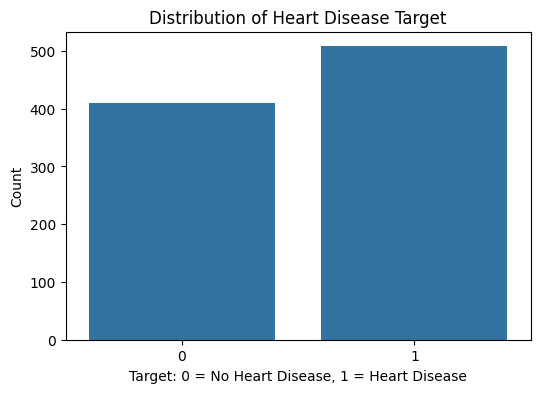

In [9]:
# ===============================
# 8. Target variable distribution
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns

print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="target")
plt.title("Distribution of Heart Disease Target")
plt.xlabel("Target: 0 = No Heart Disease, 1 = Heart Disease")
plt.ylabel("Count")
plt.show()

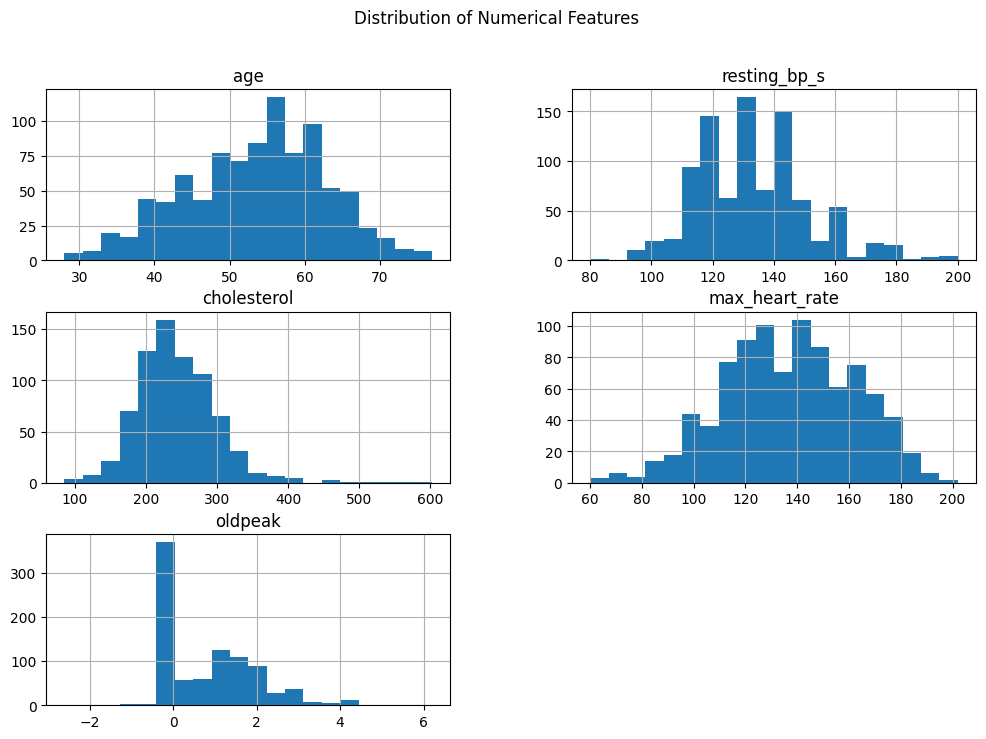

In [10]:
# ===============================
# 9. Distribution of numerical features
# ===============================

numeric_features = [
    "age",
    "resting_bp_s",
    "cholesterol",
    "max_heart_rate",
    "oldpeak"
]

df[numeric_features].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distribution of Numerical Features")
plt.show()

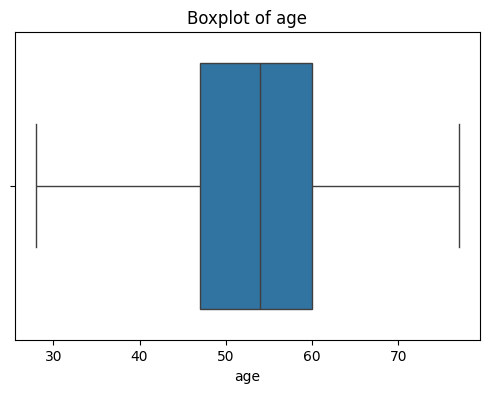

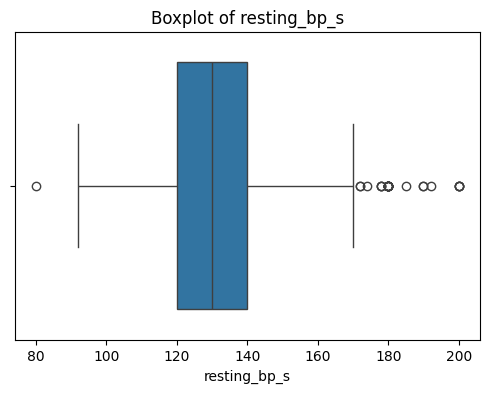

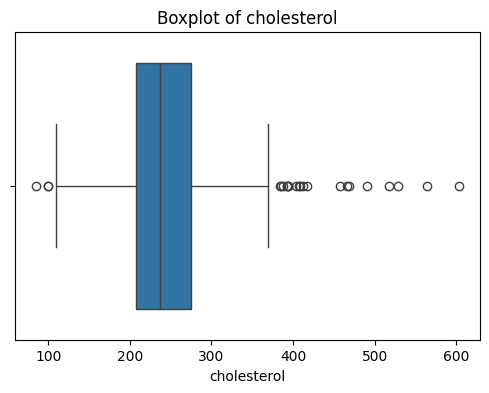

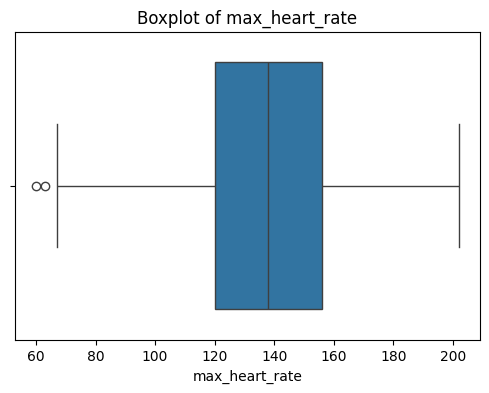

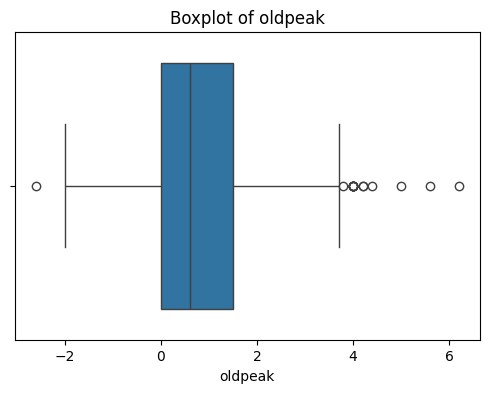

In [11]:
# ===============================
# 10. Boxplots for outlier detection
# ===============================

for col in numeric_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot of {col}")
    plt.show()

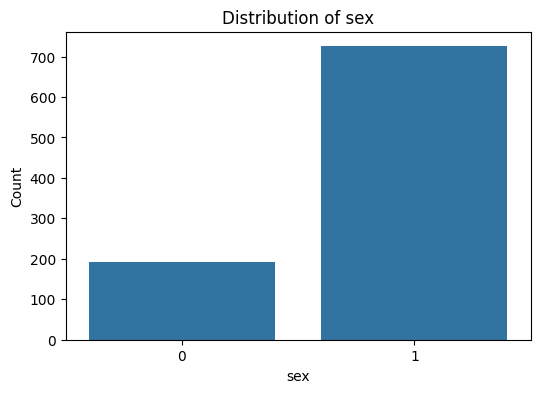

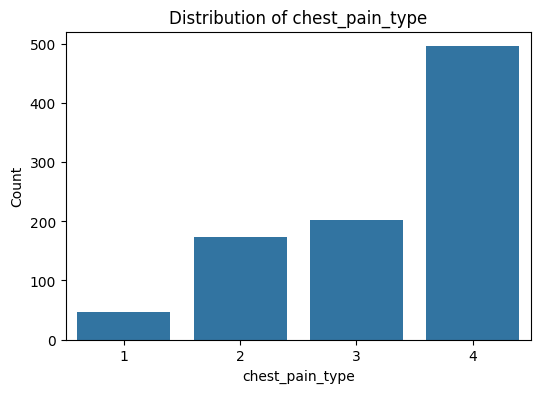

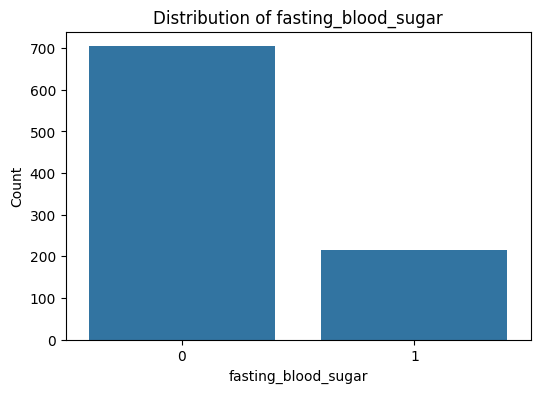

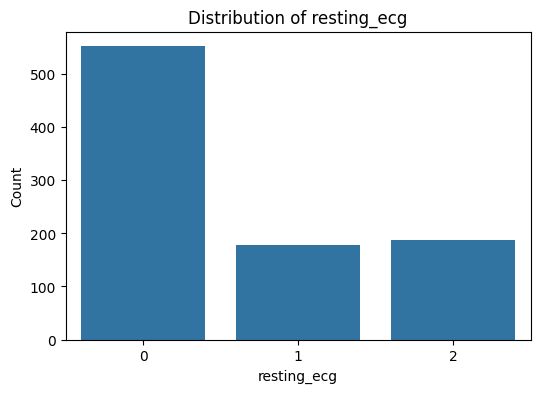

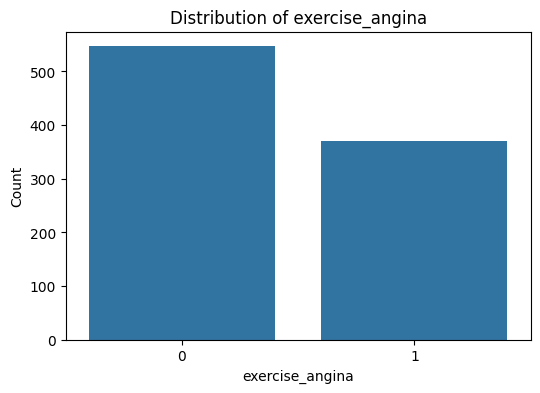

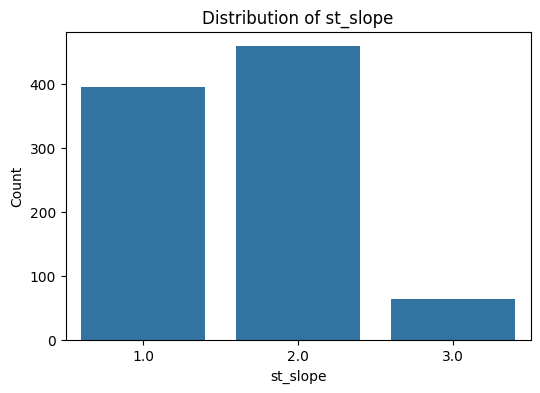

In [12]:
# ===============================
# 12. Distribution of categorical features
# ===============================

categorical_features = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_angina",
    "st_slope"
]

for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

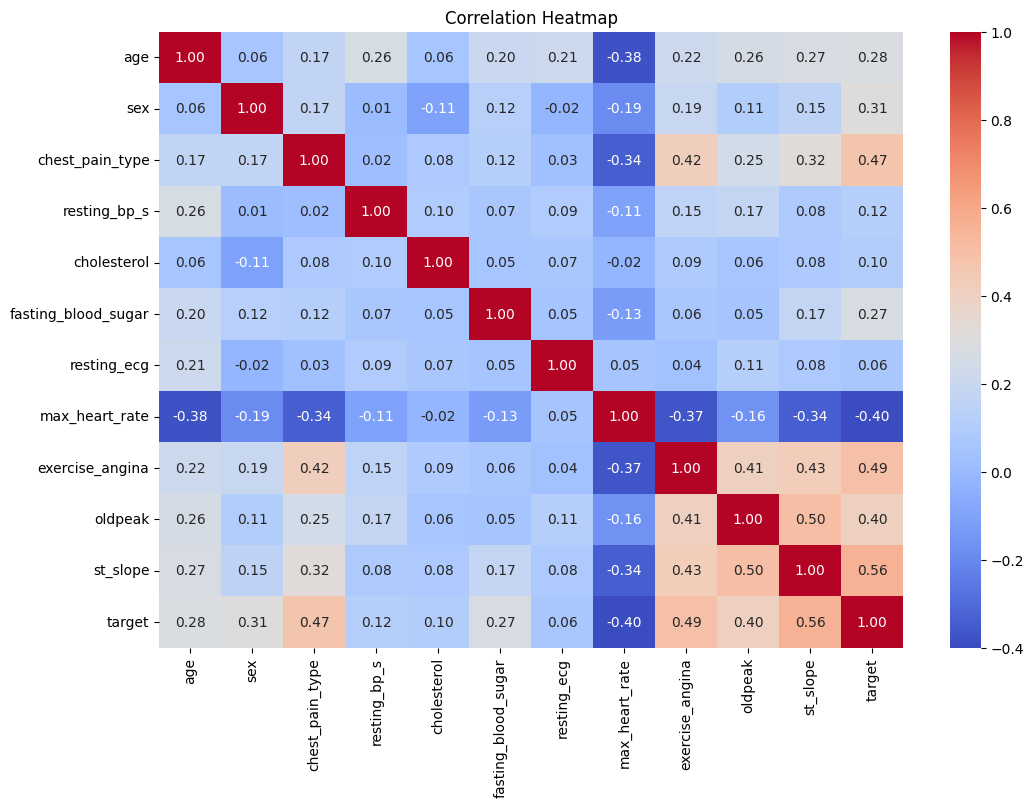

In [13]:
# ===============================
# Correlation heatmap
# ===============================

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
# ===============================
# 15. Import modeling libraries
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [16]:
# ===============================
# 16. Define features and target
# ===============================

target_col = "target"

feature_cols = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_bp_s",
    "cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_angina",
    "oldpeak",
    "st_slope"
]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (918, 11)
y shape: (918,)

Target distribution:
target
1    508
0    410
Name: count, dtype: int64


In [17]:
# ===============================
# 17. Define numerical and categorical columns
# ===============================

numeric_features = [
    "age",
    "resting_bp_s",
    "cholesterol",
    "max_heart_rate",
    "oldpeak"
]

categorical_features = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_angina",
    "st_slope"
]

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'resting_bp_s', 'cholesterol', 'max_heart_rate', 'oldpeak']
Categorical features: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg', 'exercise_angina', 'st_slope']


In [18]:
# ===============================
# 18. Train-test split
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

X_train shape: (734, 11)
X_test shape: (184, 11)
y_train shape: (734,)
y_test shape: (184,)

Training target distribution:
target
1    406
0    328
Name: count, dtype: int64

Testing target distribution:
target
1    102
0     82
Name: count, dtype: int64


In [19]:
# ===============================
# 19. Handle missing values
# ===============================

X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# Numerical columns: fill missing values using median
num_imputer = SimpleImputer(strategy="median")

X_train_processed[numeric_features] = num_imputer.fit_transform(
    X_train_processed[numeric_features]
)

X_test_processed[numeric_features] = num_imputer.transform(
    X_test_processed[numeric_features]
)

# Categorical columns: fill missing values using most frequent value
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_processed[categorical_features] = cat_imputer.fit_transform(
    X_train_processed[categorical_features]
)

X_test_processed[categorical_features] = cat_imputer.transform(
    X_test_processed[categorical_features]
)

print("Missing values in X_train after imputation:")
print(X_train_processed.isnull().sum())

print("\nMissing values in X_test after imputation:")
print(X_test_processed.isnull().sum())

Missing values in X_train after imputation:
age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
dtype: int64

Missing values in X_test after imputation:
age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
dtype: int64


In [20]:
# ===============================
# 20. Label encode categorical columns
# ===============================

label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()

    X_train_processed[col] = le.fit_transform(X_train_processed[col].astype(str))
    X_test_processed[col] = le.transform(X_test_processed[col].astype(str))

    label_encoders[col] = le

print("Label encoding completed.")

X_train_processed.head()

Label encoding completed.


,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope
486,63.0,1,1,139.0,217.0,1,1,128.0,1,1.2,1
487,55.0,1,1,110.0,214.0,1,1,180.0,0,0.4,0
117,59.0,0,3,130.0,338.0,1,1,130.0,1,1.5,1
362,47.0,1,3,160.0,238.0,0,0,124.0,1,0.0,1
297,50.0,1,3,145.0,238.0,1,0,139.0,1,0.7,1


In [21]:
# ===============================
# 21. Standard scaling
# ===============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (734, 11)
X_test_scaled shape: (184, 11)


In [22]:
# ===============================
# 22. Model evaluation function
# ===============================

model_results = []

def evaluate_model(model_name, y_true, y_pred, y_pred_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc_auc = roc_auc_score(y_true, y_pred_proba)

    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("=" * 50)
    print(model_name)
    print("=" * 50)
    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)
    print("ROC-AUC  :", roc_auc)

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Random Forest
Accuracy : 0.8804347826086957
Precision: 0.8846153846153846
Recall   : 0.9019607843137255
F1 Score : 0.8932038834951457
ROC-AUC  : 0.9276661884265902

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.88      0.88       184
weighted avg       0.88      0.88      0.88       184



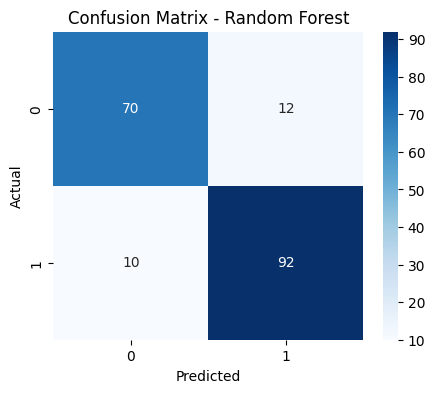

In [23]:
# ===============================
# 23. Random Forest model
# ===============================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_processed, y_train)

rf_pred = rf_model.predict(X_test_processed)
rf_pred_proba = rf_model.predict_proba(X_test_processed)[:, 1]

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_pred_proba
)

XGBoost
Accuracy : 0.8586956521739131
Precision: 0.8958333333333334
Recall   : 0.8431372549019608
F1 Score : 0.8686868686868687
ROC-AUC  : 0.9207317073170732

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        82
           1       0.90      0.84      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



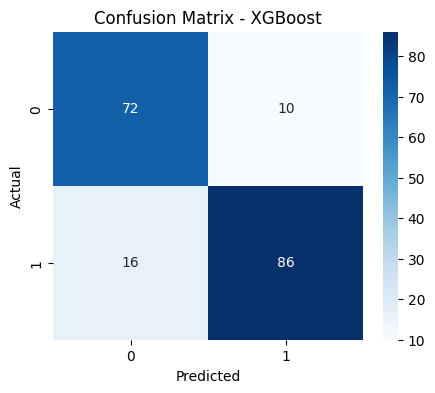

In [24]:
# ===============================
# 24. XGBoost model
# ===============================

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_processed, y_train)

xgb_pred = xgb_model.predict(X_test_processed)
xgb_pred_proba = xgb_model.predict_proba(X_test_processed)[:, 1]

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_pred_proba
)

In [25]:
# ===============================
# 25. ANN model
# ===============================

tf.random.set_seed(42)

ann_model = Sequential()

ann_model.add(Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)))
ann_model.add(Dropout(0.30))

ann_model.add(Dense(32, activation="relu"))
ann_model.add(Dropout(0.20))

ann_model.add(Dense(16, activation="relu"))

ann_model.add(Dense(1, activation="sigmoid"))

ann_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ===============================
# 26. Train ANN model
# ===============================

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.5298 - loss: 0.6839 - val_accuracy: 0.6259 - val_loss: 0.6346
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6269 - loss: 0.6084 - val_accuracy: 0.7755 - val_loss: 0.5764
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7274 - loss: 0.5423 - val_accuracy: 0.8027 - val_loss: 0.5461
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8194 - loss: 0.4890 - val_accuracy: 0.8163 - val_loss: 0.5166
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8330 - loss: 0.4162 - val_accuracy: 0.8095 - val_loss: 0.4948
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8535 - loss: 0.3655 - val_accuracy: 0.8027 - val_loss: 0.5045
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8484 - loss: 0.3636 - val_accuracy: 0.8095 - val_loss: 0.5071
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8484 - loss: 0.3612 - val_accuracy: 0.8

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
ANN
Accuracy : 0.8641304347826086
Precision: 0.8666666666666667
Recall   : 0.8921568627450981
F1 Score : 0.8792270531400966
ROC-AUC  : 0.9163079866092779

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        82
           1       0.87      0.89      0.88       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



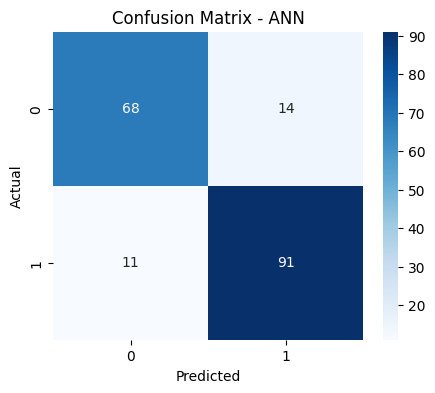

In [27]:
# ===============================
# 27. Evaluate ANN model
# ===============================

ann_pred_proba = ann_model.predict(X_test_scaled).ravel()

ann_pred = (ann_pred_proba >= 0.5).astype(int)

evaluate_model(
    "ANN",
    y_test,
    ann_pred,
    ann_pred_proba
)

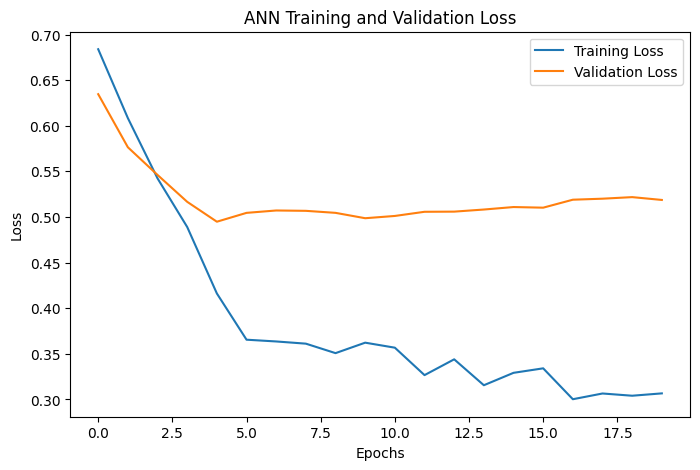

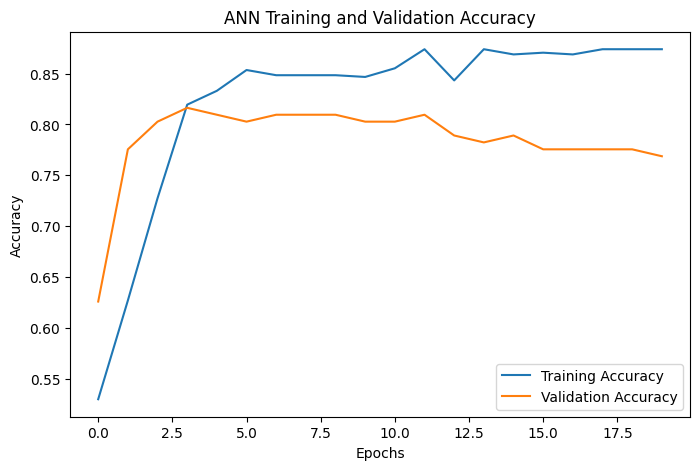

In [28]:
# ===============================
# 28. ANN training history
# ===============================

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("ANN Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [29]:
# ===============================
# 29. Compare model performance
# ===============================

results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.880435,0.884615,0.901961,0.893204,0.927666
1,XGBoost,0.858696,0.895833,0.843137,0.868687,0.920732
2,ANN,0.864130,0.866667,0.892157,0.879227,0.916308


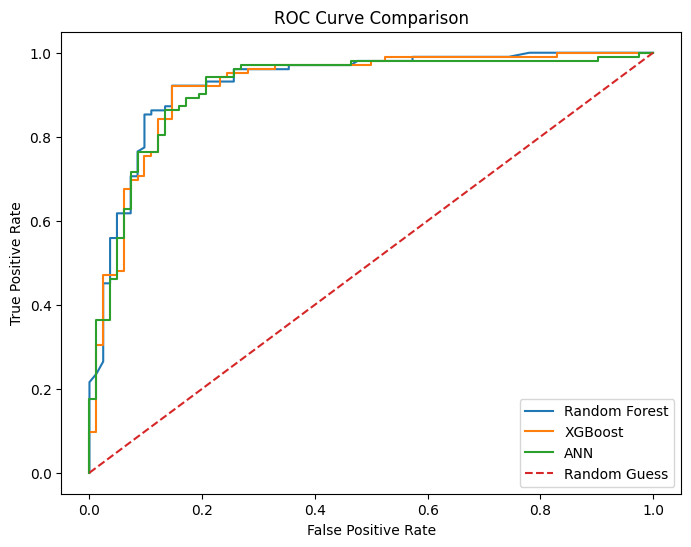

In [30]:
# ===============================
# 31. ROC curve comparison
# ===============================

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred_proba)
ann_fpr, ann_tpr, _ = roc_curve(y_test, ann_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")
plt.plot(ann_fpr, ann_tpr, label="ANN")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

<Figure size 1000x600 with 0 Axes>

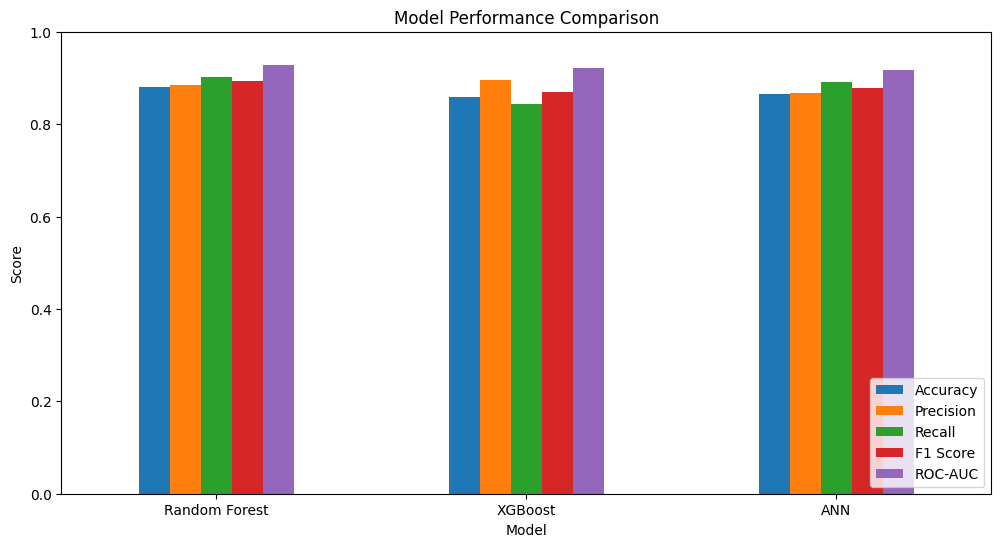

In [31]:
# ===============================
# 30. Visual comparison of models
# ===============================

plt.figure(figsize=(10, 6))

comparison_df = results_df.set_index("Model")

comparison_df[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()